<a href="https://colab.research.google.com/github/immaculatemuli/Natural_Language_Processing/blob/main/Week_1/Week_1_Extra_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

WEEK 1: EXTRA TASKS

1. STEMMING AND LEMMATIZATION

2. WORD FREQUENCY AND COUNTER VISUALIZATION

3. NLU vs NLG DEMONSTRATION

In [ ]:
#
# DATASET: CBK Annual Report & Financial Statements 2024/25
#
# Step 1: Download the PDF from the official CBK website:
#         https://www.centralbank.go.ke/reports/
#         File name: 1084981846_2025 Annual Report.pdf
#
# Step 2: Upload the PDF to Google Colab using one of these methods:
#
#           Upload directly each session:
#         from google.colab import files
#         files.upload()    ← click and select the PDF
#
#
# Step 3: Update the pdf_path variable below to match your file location


In [ ]:
# ── SETUP: Install libraries and load CBK Annual Report
!pip install PyPDF2 nltk --quiet

import PyPDF2
import nltk

nltk.download('punkt',       quiet=True)
nltk.download('punkt_tab',   quiet=True)
nltk.download('stopwords',   quiet=True)
nltk.download('wordnet',     quiet=True)

# Load CBK Annual Report 2024/25
# Pages 7–15 = Governor Foreword + Domestic Economy
pdf_path = '/content/1084981846_2025 Annual Report.pdf'

cbk_text = ''
with open(pdf_path, 'rb') as f:
    reader = PyPDF2.PdfReader(f)
    print(f'Total pages in CBK Annual Report: {len(reader.pages)}')
    for page_num in range(7, 15):
        page_text = reader.pages[page_num].extract_text()
        if page_text:
            cbk_text += page_text + ' '

print(f'Text loaded: {len(cbk_text):,} characters')
print(f'Preview: {cbk_text[:200]}')

Total pages in CBK Annual Report: 152
Text loaded: 10,266 characters
Preview: VICENTRAL BANK OF KENYA
ANNUAL REPORT & FINANCIAL STATEMENTS 2024/25
To be a World Class Modern Central BankABBREVIATIONS AND ACRONYMS  
AACB  Association of African Central Banks
ACH Automated Cleari


In [ ]:
# ── EXTRA TASK 1: Stemming and Lemmatization
# Course outline Week 1 preprocessing concept — not assigned as mandatory
# Dataset: CBK Annual Report & Financial Statements 2024/25

from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Get clean tokens from cbk_text — same as mandatory Fig 5
tokens = word_tokenize(cbk_text.lower())
filtered = [
    w for w in tokens
    if w.isalpha() and w not in stop_words
]

# Take first 20 meaningful CBK words for comparison
sample = filtered[:20]

print('=' * 65)
print('  EXTRA TASK 1 — STEMMING vs LEMMATIZATION')
print('  Dataset: CBK Annual Report & Financial Statements 2024/25')
print('  Pages: 7–14 (Governor Foreword + Domestic Economy)')
print('=' * 65)
print(f'\n{"Original Word":<22} {"Stemmed":<22} {"Lemmatized"}')
print('-' * 65)
for word in sample:
    stemmed    = stemmer.stem(word)
    lemmatized = lemmatizer.lemmatize(word)
    print(f'{word:<22} {stemmed:<22} {lemmatized}')

print('\n' + '=' * 65)
print('KEY OBSERVATIONS FROM CBK TEXT:')
print('  Stemming cuts words roughly — may produce non-real words')
print('  e.g. "stability" → "stabil" (not a real word)')
print('  Lemmatization finds real dictionary base forms')
print('  e.g. "policies" → "policy" (real word, correct base)')
print('  For financial text like CBK reports, lemmatization')
print('  is more accurate because financial terms must stay readable.')
print('=' * 65)

  EXTRA TASK 1 — STEMMING vs LEMMATIZATION
  Dataset: CBK Annual Report & Financial Statements 2024/25
  Pages: 7–14 (Governor Foreword + Domestic Economy)

Original Word          Stemmed                Lemmatized
-----------------------------------------------------------------
vicentral              vicentr                vicentral
bank                   bank                   bank
kenya                  kenya                  kenya
annual                 annual                 annual
report                 report                 report
financial              financi                financial
statements             statement              statement
world                  world                  world
class                  class                  class
modern                 modern                 modern
central                central                central
bankabbreviations      bankabbrevi            bankabbreviations
acronyms               acronym                acronym
aacb          

  EXTRA TASK 2 — WORD FREQUENCY COUNTER
  Dataset: CBK Annual Report & Financial Statements 2024/25
  Pages: 7–14 (Governor Foreword + Domestic Economy)

Top 15 Most Frequent Words in the CBK Report:

  Rank   Word                  Count  Bar
  --------------------------------------------------
  1      bank                     26  ██████████████████████████
  2      financial                19  ███████████████████
  3      kenya                    17  █████████████████
  4      central                  16  ████████████████
  5      monetary                 13  █████████████
  6      cbk                      11  ███████████
  7      system                   11  ███████████
  8      annual                   10  ██████████
  9      report                   10  ██████████
  10     world                    10  ██████████
  11     banks                    10  ██████████
  12     statements                9  █████████
  13     class                     9  █████████
  14     modern           

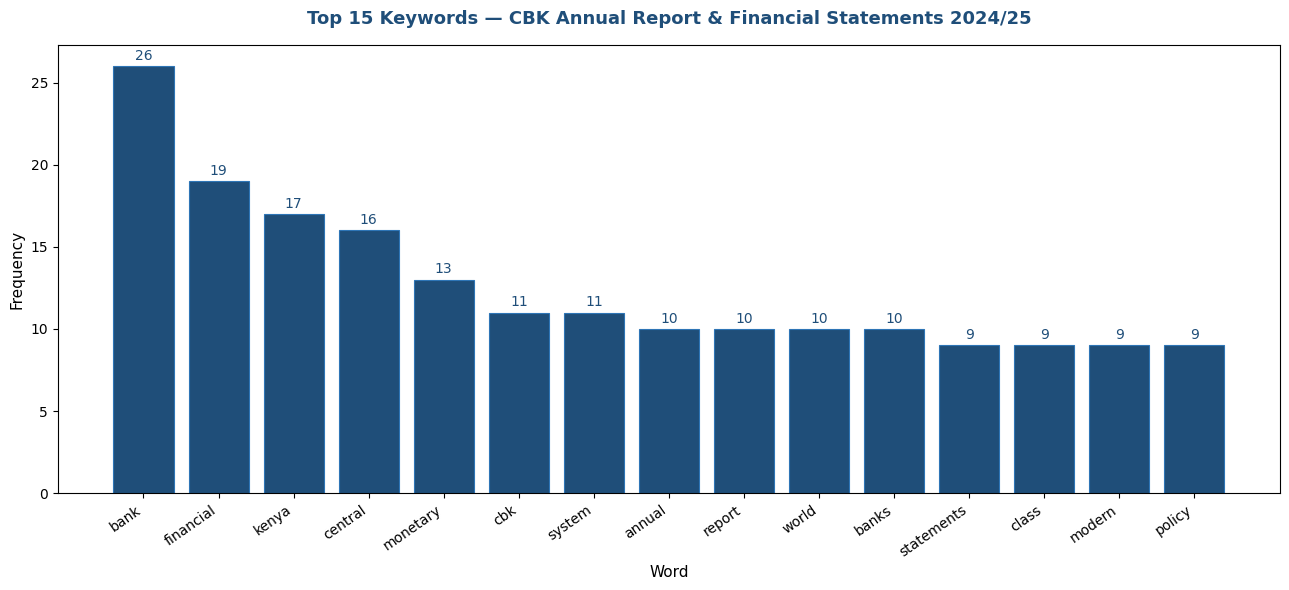


Chart saved as cbk_word_frequency.png
The dominant words reveal the CBK report core themes.
Expected: monetary, bank, policy, inflation, percent


In [ ]:
# ── EXTRA TASK 2: Word Frequency Counter and Visualization
# Course outline Practical 2 — extended with visualization
# Dataset: CBK Annual Report & Financial Statements 2024/25

import matplotlib.pyplot as plt
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

!pip install matplotlib --quiet

stop_words = set(stopwords.words('english'))

# Clean tokens from CBK text
tokens = word_tokenize(cbk_text.lower())
clean  = [
    w for w in tokens
    if w.isalpha() and w not in stop_words and len(w) > 2
]

freq   = Counter(clean)
top15  = freq.most_common(15)

#  Printed frequency table
print('=' * 55)
print('  EXTRA TASK 2 — WORD FREQUENCY COUNTER')
print('  Dataset: CBK Annual Report & Financial Statements 2024/25')
print('  Pages: 7–14 (Governor Foreword + Domestic Economy)')
print('=' * 55)
print('\nTop 15 Most Frequent Words in the CBK Report:')
print(f'\n  {"Rank":<6} {"Word":<20} {"Count":>6}  {"Bar"}')
print('  ' + '-' * 50)
for rank, (word, count) in enumerate(top15, 1):
    bar = '█' * count
    print(f'  {rank:<6} {word:<20} {count:>6}  {bar}')

#  Bar chart
words, counts = zip(*top15)

plt.figure(figsize=(13, 6))
bars = plt.bar(words, counts, color='#1F4E79', edgecolor='#2E75B6', linewidth=0.8)

# Add count labels on top of each bar
for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        str(count),
        ha='center', va='bottom', fontsize=10, color='#1F4E79'
    )

plt.title(
    'Top 15 Keywords — CBK Annual Report & Financial Statements 2024/25',
    fontsize=13, fontweight='bold', color='#1F4E79', pad=15
)
plt.xlabel('Word', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.tight_layout()
plt.savefig('cbk_word_frequency.png', dpi=150)
plt.show()

print('\nChart saved as cbk_word_frequency.png')
print('The dominant words reveal the CBK report core themes.')
print('Expected: monetary, bank, policy, inflation, percent')

In [ ]:
# ── EXTRA TASK 3: NLU vs NLG Demonstration
# Course outline Week 1 concept: NLU and NLG
# Dataset: CBK Annual Report & Financial Statements 2024/25

import re
from nltk.tokenize import sent_tokenize

print('=' * 60)
print('  EXTRA TASK 3 — NLU vs NLG DEMONSTRATION')
print('  Dataset: CBK Annual Report & Financial Statements 2024/25')
print('=' * 60)

# NLU SIDE: Machine reads CBK text and extracts meaning
print('\n--- NLU (Natural Language UNDERSTANDING) ---')
print('The machine reads the CBK report and extracts structured data:\n')

# Extract all percentages
percentages = re.findall(r'\d+\.?\d*\s*percent', cbk_text)
unique_pct  = list(dict.fromkeys(percentages))
print(f'Percentages found in report: {unique_pct[:8]}')

# Extract all years mentioned
years = sorted(set(re.findall(r'\b20[0-9]{2}\b', cbk_text)))
print(f'Years mentioned:             {years}')

# Extract KSh amounts
ksh_values = re.findall(r'KSh\s+[\d,.]+\s*\w+', cbk_text)
unique_ksh  = list(dict.fromkeys(ksh_values))
print(f'KSh figures found:           {unique_ksh[:5]}')

# Count sentences and words
sentences  = sent_tokenize(cbk_text)
word_count = len([w for w in cbk_text.split() if w.isalpha()])
print(f'Total sentences:             {len(sentences)}')
print(f'Total words:                 {word_count:,}')

# NLG SIDE: Machine uses that data to generate sentences
print('\n--- NLG (Natural Language GENERATION) ---')
print('The machine uses the extracted data to write sentences:\n')

if percentages:
    nlg_1 = (
        f'The CBK Annual Report 2024/25 references {len(unique_pct)} '
        f'distinct percentage figures, ranging from {unique_pct[-1]} '
        f'to {unique_pct[0]}.'
    )
    print(f'Generated sentence 1:')
    print(f'  "{nlg_1}"\n')

if years:
    nlg_2 = (
        f'The report covers financial developments across '
        f'{len(years)} years: {", ".join(years)}.'
    )
    print(f'Generated sentence 2:')
    print(f'  "{nlg_2}"\n')

nlg_3 = (
    f'The extracted CBK dataset contains {len(sentences)} sentences '
    f'and {word_count:,} words, making it a rich source for NLP analysis.'
)
print(f'Generated sentence 3:')
print(f'  "{nlg_3}"\n')

print('=' * 60)
print('CONCLUSION:')
print('  NLU = machine reads text and extracts numbers, dates,')
print('        percentages — structured meaning from unstructured text.')
print('  NLG = machine uses that structured data to write new sentences.')
print('  Together they form the complete NLP pipeline used in')
print('  tools like ChatGPT, Google Translate, and CBK report tools.')
print('=' * 60)

  EXTRA TASK 3 — NLU vs NLG DEMONSTRATION
  Dataset: CBK Annual Report & Financial Statements 2024/25

--- NLU (Natural Language UNDERSTANDING) ---
The machine reads the CBK report and extracts structured data:

Percentages found in report: ['3.8 percent', '4.6 percent', '13.00 percent', '9.75 percent']
Years mentioned:             ['2019', '2024', '2025', '2027', '2029']
KSh figures found:           ['KSh 10 billion', 'KSh 50 billion', 'KSh 100 billion', 'KSh 60 billion', 'KSh 1 billion']
Total sentences:             42
Total words:                 1,262

--- NLG (Natural Language GENERATION) ---
The machine uses the extracted data to write sentences:

Generated sentence 1:
  "The CBK Annual Report 2024/25 references 4 distinct percentage figures, ranging from 9.75 percent to 3.8 percent."

Generated sentence 2:
  "The report covers financial developments across 5 years: 2019, 2024, 2025, 2027, 2029."

Generated sentence 3:
  "The extracted CBK dataset contains 42 sentences and 1,262 